# Standard Random Forest Training — 2 Models (Blind + BlindDir)

Trains two gesture-classification models from the `preprocessed1.csv` hand-tracking dataset:

1. **standard_blind** — 5 features (palm-to-fingertip distances)
2. **standard_blind_dir** — 8 features (5 distances + 3 direction components)

Both models train on the **raw continuous data stream** (no time-window aggregation) and use **GridSearchCV** (5-fold stratified CV) to find the best Random Forest hyperparameters.

### Gesture Classes
| Class | Gesture |
|-------|---------|
| 1 | Open palm |
| 2 | Fist |
| 3 | Thumb only |
| 4 | Pinky only |
| 5 | Horns (index + ring + thumb) |
| 6 | Thumb + pinky |

## 1. Imports & Configuration

In [11]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
)
import time
from IPython.display import display, clear_output
import warnings
warnings.filterwarnings('ignore')

# Inline plots
%matplotlib inline
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

In [12]:
# --- Paths ---
NOTEBOOK_DIR = os.path.abspath('')
DATASET_PATH = os.path.join(NOTEBOOK_DIR, "Dataset", "preprocessed1.csv")

# Gesture label mapping
GESTURE_LABELS = {
    1: "Open palm",
    2: "Fist",
    3: "Thumb only",
    4: "Pinky only",
    5: "Horns (ind+ring+thu)",
    6: "Thumb + pinky",
}


# Direction columns present in the dataset
DIRECTION_COLS = ["direction_x", "direction_y", "direction_z"]

# Hyperparameter grid for GridSearchCV
PARAM_GRID = {
    'n_estimators':      [50, 100, 200],
    'max_depth':         [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf':  [1, 2],
}

# Model configurations
MODEL_CONFIGS = [
    {
        'name':          'standard_blind',
        'use_direction': False,
        'n_features':    5,
        'description':   '5 distance features (palm -> fingertip)',
        'color':         '#27ae60',
    },
    {
        'name':          'standard_blind_dir',
        'use_direction': True,
        'n_features':    8,
        'description':   '5 distances + 3 direction components',
        'color':         '#8e44ad',
    },
]

n_comb = 1
for v in PARAM_GRID.values():
    n_comb *= len(v)

print(f"Dataset:                       {DATASET_PATH}")
print(f"Total HP combinations/model:   {n_comb}")
print(f"Trainings per model (x5 fold): {n_comb * 5}")


Dataset:                       c:\Users\ricca\OneDrive - University of Pisa\Andrea Diano's files - HMC Neuromorphic Project\Final_Lab\Python\Dataset\preprocessed1.csv
Total HP combinations/model:   36
Trainings per model (x5 fold): 180


## 2. Data Loading

In [13]:
def load_dataset(path):
    """Load preprocessed1.csv — only the columns we need, in float32 to save RAM."""
    usecols = (
        ['timestamp', 'class',
         'palm_x', 'palm_y', 'palm_z',
         'direction_x', 'direction_y', 'direction_z']
        + [f'ch_{i}_{ax}' for i in range(1, 6) for ax in ('x', 'y', 'z')]
        + [f'ch_{i}_missing' for i in range(1, 6)]
    )
    print(f"[LOAD] Reading: {os.path.basename(path)} ({len(usecols)} columns)")
    df = pd.read_csv(path, usecols=usecols, dtype={c: np.float32
                     for c in usecols if c != 'class'})
    print(f"   Rows: {len(df):,}  |  Columns: {df.shape[1]}")
    return df

df = load_dataset(DATASET_PATH)
df.head()

[LOAD] Reading: preprocessed1.csv (28 columns)
   Rows: 532,273  |  Columns: 28


,timestamp,class,palm_x,palm_y,palm_z,direction_x,direction_y,direction_z,ch_1_x,ch_1_y,...,ch_4_y,ch_4_z,ch_5_x,ch_5_y,ch_5_z,ch_1_missing,ch_2_missing,ch_3_missing,ch_4_missing,ch_5_missing
0,2193.313965,1,-43.532001,185.225006,-2.645,0.41,-0.034,-0.911,-13.006,182.014008,...,186.039993,-74.612999,32.504002,183.292007,26.731001,0.0,0.0,0.0,0.0,0.0
1,2193.314941,1,-43.532001,185.225006,-2.645,0.41,-0.034,-0.911,-13.006,182.014008,...,186.039993,-74.612999,32.504002,183.292007,26.731001,0.0,0.0,0.0,0.0,0.0
2,2193.318115,1,-43.532001,185.225006,-2.645,0.41,-0.034,-0.911,-13.006,182.014008,...,186.039993,-74.612999,32.504002,183.292007,26.731001,0.0,0.0,0.0,0.0,0.0
3,2193.320068,1,-43.532001,185.225006,-2.645,0.41,-0.034,-0.911,-13.006,182.014008,...,186.039993,-74.612999,32.504002,183.292007,26.731001,0.0,0.0,0.0,0.0,0.0
4,2193.321045,1,-43.532001,185.225006,-2.645,0.41,-0.034,-0.911,-13.006,182.014008,...,186.039993,-74.612999,32.504002,183.292007,26.731001,0.0,0.0,0.0,0.0,0.0


### Class Distribution

In [14]:
print("Class distribution (raw samples):")
for cls_id, count in df["class"].value_counts().sort_index().items():
    label = GESTURE_LABELS.get(cls_id, f"Class {cls_id}")
    print(f"   Class {cls_id} ({label}): {count:,}")

Class distribution (raw samples):
   Class 1 (Open palm): 86,244
   Class 2 (Fist): 90,514
   Class 3 (Thumb only): 90,486
   Class 4 (Pinky only): 93,002
   Class 5 (Horns (ind+ring+thu)): 84,644
   Class 6 (Thumb + pinky): 87,383


## 3. Feature Extraction — Euclidean Distances (palm → fingertip)

In [15]:
def compute_distances(df):
    """
    For each of the 5 fingers, compute the 3-D Euclidean distance
    from the palm centre to the fingertip.

    If the finger is missing (ch_X_missing == 1), the distance is set to 0
    (zero-padding).

    Returns the DataFrame with 5 new columns: dist_1 .. dist_5.
    """
    palm_cols = ["palm_x", "palm_y", "palm_z"]
    drop_cols = list(palm_cols)

    for i in range(1, 6):
        tip_cols = [f"ch_{i}_x", f"ch_{i}_y", f"ch_{i}_z"]
        missing_col = f"ch_{i}_missing"

        # Vectorised Euclidean distance
        dx = df[tip_cols[0]].values - df[palm_cols[0]].values
        dy = df[tip_cols[1]].values - df[palm_cols[1]].values
        dz = df[tip_cols[2]].values - df[palm_cols[2]].values
        dist = np.sqrt(dx**2 + dy**2 + dz**2).astype(np.float32)

        # Zero-pad where the finger data is missing
        missing_mask = df[missing_col].values == 1
        dist[missing_mask] = 0.0

        df[f"dist_{i}"] = dist
        drop_cols.extend(tip_cols + [missing_col])

    print("[FEAT] Computed 5 Euclidean-distance channels (palm -> fingertip).")
    n_missing_cols = [f"ch_{i}_missing" for i in range(1, 6)]
    n_missing = (df[n_missing_cols] == 1).sum()
    for i in range(1, 6):
        pct = n_missing[f"ch_{i}_missing"] / len(df) * 100
        print(f"   ch_{i}: {n_missing[f'ch_{i}_missing']:,} missing rows "
              f"({pct:.1f}%) -> padded with 0")

    # Free memory by dropping raw coordinate + missing columns
    df = df.drop(columns=drop_cols)
    import gc; gc.collect()
    print(f"[MEM]  Dropped {len(drop_cols)} raw columns to free memory.")

    return df

df = compute_distances(df)

[FEAT] Computed 5 Euclidean-distance channels (palm -> fingertip).
   ch_1: 54,446 missing rows (10.2%) -> padded with 0
   ch_2: 222,512 missing rows (41.8%) -> padded with 0
   ch_3: 345,152 missing rows (64.8%) -> padded with 0
   ch_4: 442,484 missing rows (83.1%) -> padded with 0
   ch_5: 446,029 missing rows (83.8%) -> padded with 0
[MEM]  Dropped 23 raw columns to free memory.


In [16]:
print("Direction channels summary (raw):")
for col in DIRECTION_COLS:
    print(f"   {col}: mean={df[col].mean():.4f}, "
          f"std={df[col].std():.4f}, "
          f"min={df[col].min():.4f}, max={df[col].max():.4f}")

Direction channels summary (raw):
   direction_x: mean=-8.1045, std=91.0745, min=-1000.0000, max=0.9370
   direction_y: mean=-8.3616, std=91.0504, min=-1000.0000, max=0.5060
   direction_z: mean=-9.2209, std=90.9714, min=-1000.0000, max=-0.3470


## 4. Prepare Features for Training

Select the relevant feature columns (distances and optionally direction) from the raw continuous data for each model configuration.

In [17]:
def prepare_features(df, include_direction=False):
    """
    Select feature columns and target from the raw continuous data stream.

    No time-window aggregation is applied — every sample in the dataset
    is used individually for training.

    Parameters
    ----------
    df : DataFrame
        Must contain columns: class, dist_1..dist_5.
        If include_direction=True, must also contain direction_x/y/z.
    include_direction : bool
        Whether to include direction columns.

    Returns
    -------
    X : ndarray
        Feature matrix.
    y : ndarray
        Target labels.
    feature_cols : list[str]
        Names of the feature columns used.
    """
    dist_cols = [f"dist_{i}" for i in range(1, 6)]
    if include_direction:
        feature_cols = dist_cols + DIRECTION_COLS
    else:
        feature_cols = dist_cols

    X = df[feature_cols].values
    y = df["class"].values

    print(f"[DATA] Using raw continuous stream: {len(y):,} samples, "
          f"{len(feature_cols)} features.")

    return X, y, feature_cols


## 5. Training Function

In [18]:
def train_model(X, y, config_name):
    """
    Run GridSearchCV with 5-fold stratified CV and return the best model.
    Shows a live text-based progress bar with percentage, ETA and current params.
    """
    from itertools import product
    from sklearn.metrics import f1_score

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    n_folds = skf.get_n_splits()

    # Expand parameter grid
    param_keys = list(PARAM_GRID.keys())
    param_combos = list(product(*[PARAM_GRID[k] for k in param_keys]))
    n_combos = len(param_combos)
    total_fits = n_combos * n_folds

    print(f"[GRID] {n_combos} param combos \u00d7 {n_folds} folds = {total_fits} fits")
    print(f"[GRID] Dataset: {X.shape[0]:,} samples, {X.shape[1]} features")
    print()

    results = []
    done = 0
    t_start = time.time()
    best_acc_so_far = 0.0

    for combo_idx, combo in enumerate(param_combos):
        params = dict(zip(param_keys, combo))
        fold_acc = []
        fold_f1 = []

        for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X, y)):
            X_tr, X_val = X[train_idx], X[val_idx]
            y_tr, y_val = y[train_idx], y[val_idx]

            rf = RandomForestClassifier(
                **params, random_state=42, n_jobs=-1, class_weight="balanced")
            rf.fit(X_tr, y_tr)
            y_pred = rf.predict(X_val)

            fold_acc.append(accuracy_score(y_val, y_pred))
            fold_f1.append(f1_score(y_val, y_pred, average="macro"))

            done += 1
            elapsed = time.time() - t_start
            pct = done / total_fits * 100
            eta = (elapsed / done) * (total_fits - done) if done > 0 else 0

            # Build progress bar
            bar_len = 30
            filled = int(bar_len * done / total_fits)
            bar = "\u2588" * filled + "\u2591" * (bar_len - filled)

            depth_s = str(params["max_depth"]) if params["max_depth"] is not None else "None"
            status = (
                f"\r  {bar} {pct:5.1f}%  |  {done}/{total_fits} fits  |  "
                f"elapsed {elapsed:.0f}s  |  ETA {eta:.0f}s  |  "
                f"best_acc={best_acc_so_far:.4f}  |  "
                f"n_est={params['n_estimators']}, depth={depth_s}"
            )
            print(status, end="", flush=True)

        mean_acc = np.mean(fold_acc)
        if mean_acc > best_acc_so_far:
            best_acc_so_far = mean_acc

        results.append({
            "params": params,
            "mean_acc": mean_acc,
            "std_acc":  np.std(fold_acc),
            "mean_f1":  np.mean(fold_f1),
            "std_f1":   np.std(fold_f1),
        })

    total_elapsed = time.time() - t_start
    print()  # newline after progress bar
    print(f"\n[TIME] GridSearch completed in {total_elapsed/60:.1f} min ({total_elapsed:.0f}s)")

    # Find best by accuracy
    best = max(results, key=lambda r: r["mean_acc"])
    bp = best["params"]
    acc_mean, acc_std = best["mean_acc"], best["std_acc"]
    f1_mean, f1_std   = best["mean_f1"],  best["std_f1"]

    # Final model retrained on the full dataset with best params
    print(f"[REFIT] Training final model on all {len(y):,} samples...")
    t_refit = time.time()
    rf_final = RandomForestClassifier(
        **bp, random_state=42, n_jobs=-1, class_weight="balanced")
    rf_final.fit(X, y)
    print(f"[REFIT] Done in {time.time() - t_refit:.1f}s")

    depth_str = str(bp["max_depth"]) if bp["max_depth"] is not None else "None"
    print(f'  {config_name:<25s} | Acc: {acc_mean:.4f} +/- {acc_std:.4f} | '
          f'F1: {f1_mean:.4f} +/- {f1_std:.4f}')
    print(f'  {"":25s} | n_est={bp["n_estimators"]:>3}, depth={depth_str:<4}, '
          f'split={bp["min_samples_split"]}, leaf={bp["min_samples_leaf"]}')

    metrics = {
        "Model": config_name,
        "Accuracy": acc_mean, "Acc_Std": acc_std,
        "F1_Macro": f1_mean, "F1_Std": f1_std,
        "n_estimators": bp["n_estimators"],
        "max_depth": bp["max_depth"],
        "min_samples_split": bp["min_samples_split"],
        "min_samples_leaf": bp["min_samples_leaf"],
        "Samples": len(y),
    }

    return rf_final, metrics


## 6. Evaluation & Visualisation

In [19]:
def plot_confusion_matrix(model, X, y, model_name, feature_names):
    """
    Generate confusion matrix plots (absolute + normalized)
    and feature importance bar chart for the given model
    using cross-validated predictions.
    """
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    y_pred = cross_val_predict(model, X, y, cv=skf)
    acc = accuracy_score(y, y_pred)

    unique_classes = sorted(np.unique(y))
    target_names = [GESTURE_LABELS.get(c, f"Class {c}") for c in unique_classes]

    # Classification report
    print(f"\n{'='*70}")
    print(f"Classification Report — {model_name}")
    print(f"{'='*70}")
    print(classification_report(y, y_pred,
                                labels=unique_classes,
                                target_names=target_names))

    # Feature importance (text)
    importances = model.feature_importances_
    print(f"Feature Importance — {model_name}:")
    for feat, imp in zip(feature_names, importances):
        bar = "#" * int(imp * 50)
        print(f"   {feat}: {imp:.4f}  {bar}")

    # --- Confusion matrix plot ---
    cm = confusion_matrix(y, y_pred, labels=unique_classes)
    cm_norm = confusion_matrix(y, y_pred, labels=unique_classes, normalize="true")

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=target_names, yticklabels=target_names,
                ax=axes[0], linewidths=.5, linecolor="gray",
                cbar_kws={"label": "Count"})
    axes[0].set_xlabel("Predicted", fontsize=12, fontweight="bold")
    axes[0].set_ylabel("True", fontsize=12, fontweight="bold")
    axes[0].set_title("Confusion Matrix (Counts)", fontsize=13, fontweight="bold")
    axes[0].tick_params(axis="x", rotation=30)

    sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Greens",
                xticklabels=target_names, yticklabels=target_names,
                ax=axes[1], linewidths=.5, linecolor="gray",
                vmin=0, vmax=1,
                cbar_kws={"label": "Proportion"})
    axes[1].set_xlabel("Predicted", fontsize=12, fontweight="bold")
    axes[1].set_ylabel("True", fontsize=12, fontweight="bold")
    axes[1].set_title("Confusion Matrix (Normalized)", fontsize=13, fontweight="bold")
    axes[1].tick_params(axis="x", rotation=30)

    fig.suptitle(
        f"Random Forest — {model_name}\n"
        f"CV Accuracy: {acc * 100:.2f}%  |  Features: {len(feature_names)}",
        fontsize=14, fontweight="bold", y=1.02,
    )
    plt.tight_layout()
    plt.show()

    # --- Feature importance bar chart ---
    fig2, ax = plt.subplots(figsize=(10, max(4, len(feature_names) * 0.6)))
    n_feat = len(feature_names)
    if n_feat <= 5:
        display_labels = ["Channel 1", "Channel 2", "Channel 3", "Channel 4", "Channel 5"]
    else:
        display_labels = (["Channel 1 (dist)", "Channel 2 (dist)", "Channel 3 (dist)",
                           "Channel 4 (dist)", "Channel 5 (dist)"]
                          + ["Direction X", "Direction Y", "Direction Z"])

    # Two-tone colour palette for distances vs directions
    dist_colors = sns.color_palette("viridis", 5)
    dir_colors = sns.color_palette("magma", 3) if n_feat > 5 else []
    colors = dist_colors + dir_colors

    bars = ax.barh(display_labels[:n_feat], importances, color=colors[:n_feat],
                   edgecolor="black")
    ax.set_xlabel("Importance", fontsize=12, fontweight="bold")
    ax.set_title(f"Feature Importance — {model_name}",
                 fontsize=13, fontweight="bold")
    ax.invert_yaxis()
    for bar, imp in zip(bars, importances):
        ax.text(bar.get_width() + 0.005,
                bar.get_y() + bar.get_height() / 2,
                f"{imp:.4f}", va="center", fontsize=10)
    plt.tight_layout()
    plt.show()

    return acc

## 7. Train Both Models


  MODEL 1/2 — STANDARD_BLIND (5 distance features (palm -> fingertip))

[DATA] Using raw continuous stream: 532,273 samples, 5 features.
[DATA] Feature matrix shape: (532273, 5)
[DATA] Feature names: ['dist_1', 'dist_2', 'dist_3', 'dist_4', 'dist_5']

[GRID] 36 param combos × 5 folds = 180 fits
[GRID] Dataset: 532,273 samples, 5 features

  ██████████████████████████████ 100.0%  |  180/180 fits  |  elapsed 850s  |  ETA 0s  |  best_acc=0.9932  |  n_est=200, depth=2000ne

[TIME] GridSearch completed in 14.2 min (850s)
[REFIT] Training final model on all 532,273 samples...
[REFIT] Done in 10.8s
  standard_blind            | Acc: 0.9932 +/- 0.0002 | F1: 0.9933 +/- 0.0002
                            | n_est=200, depth=None, split=2, leaf=2

[TOTAL] Model standard_blind completed in 14.3 min

Classification Report — standard_blind
                      precision    recall  f1-score   support

           Open palm       1.00      1.00      1.00     86244
                Fist       0.97      

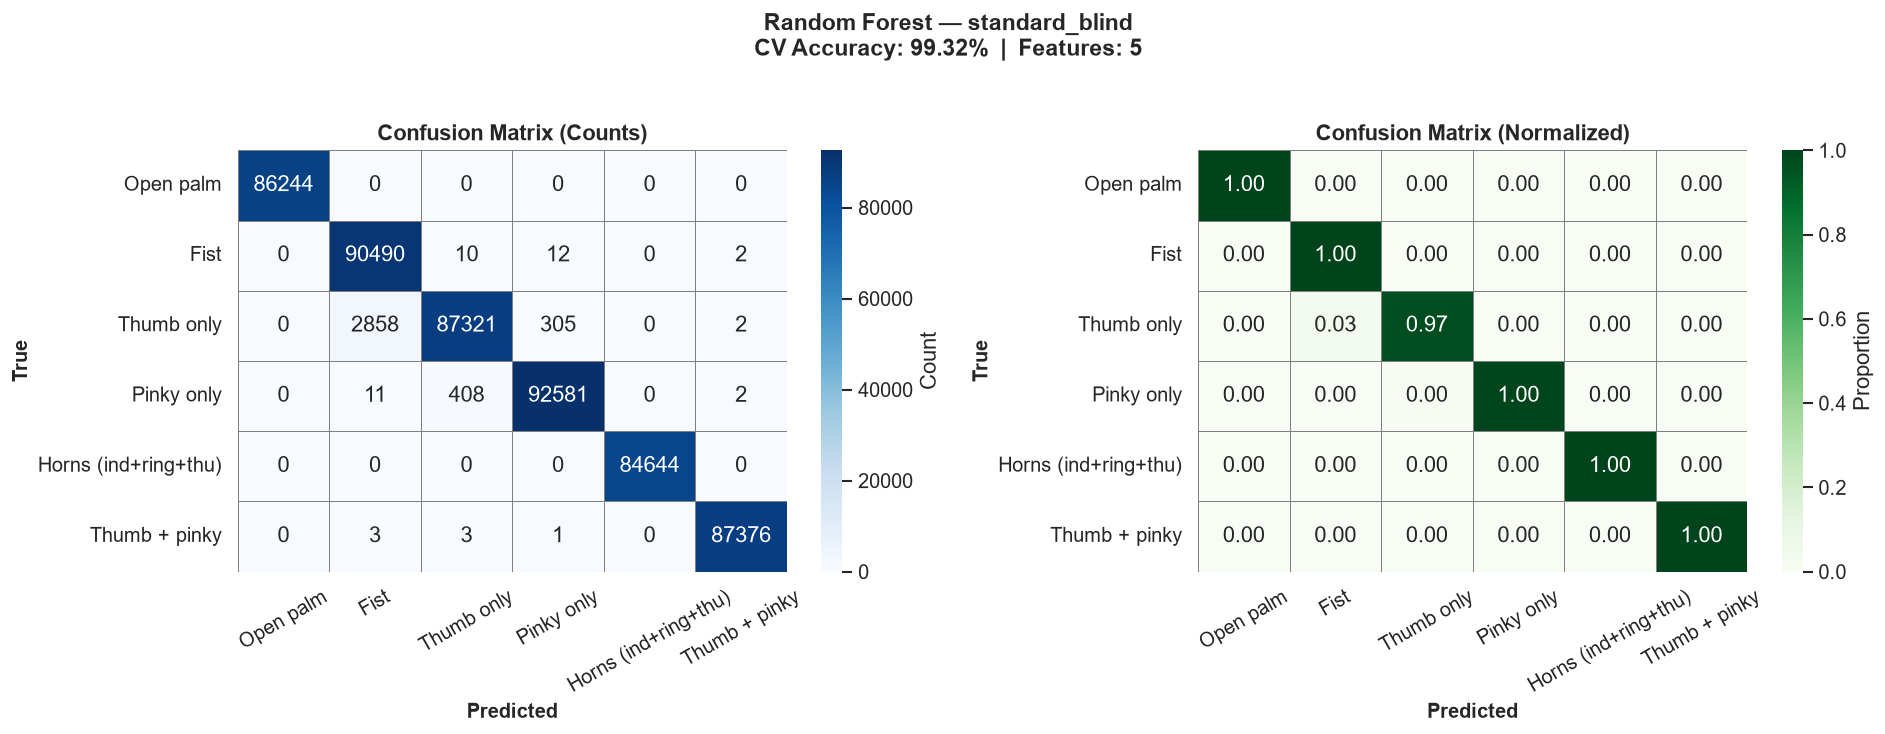

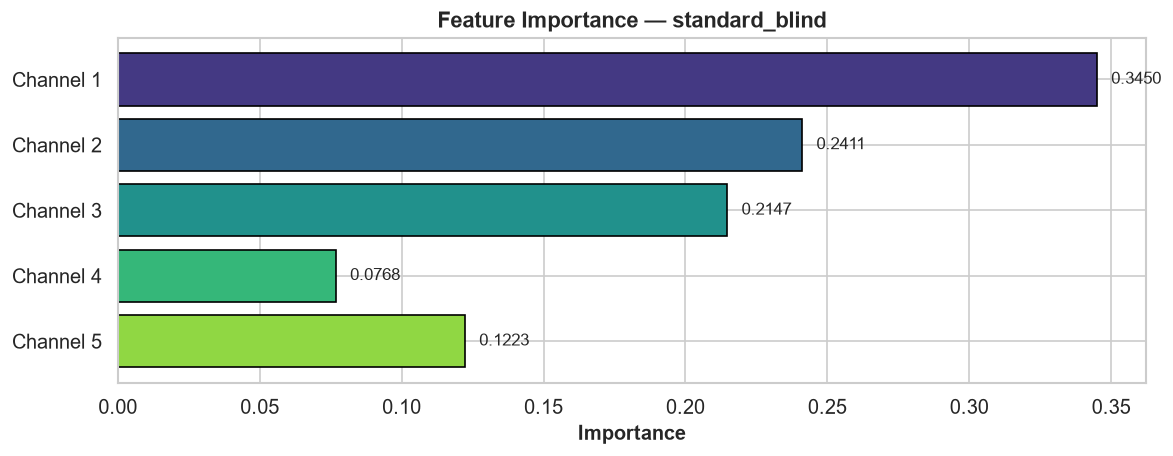


  MODEL 2/2 — STANDARD_BLIND_DIR (5 distances + 3 direction components)

[DATA] Using raw continuous stream: 532,273 samples, 8 features.
[DATA] Feature matrix shape: (532273, 8)
[DATA] Feature names: ['dist_1', 'dist_2', 'dist_3', 'dist_4', 'dist_5', 'direction_x', 'direction_y', 'direction_z']

[GRID] 36 param combos × 5 folds = 180 fits
[GRID] Dataset: 532,273 samples, 8 features

  ██████████████████████████████ 100.0%  |  180/180 fits  |  elapsed 862s  |  ETA 0s  |  best_acc=0.9999  |  n_est=200, depth=2000ne

[TIME] GridSearch completed in 14.4 min (862s)
[REFIT] Training final model on all 532,273 samples...
[REFIT] Done in 2.8s
  standard_blind_dir        | Acc: 0.9999 +/- 0.0000 | F1: 0.9999 +/- 0.0000
                            | n_est= 50, depth=None, split=5, leaf=1

[TOTAL] Model standard_blind_dir completed in 14.4 min

Classification Report — standard_blind_dir
                      precision    recall  f1-score   support

           Open palm       1.00      1.00     

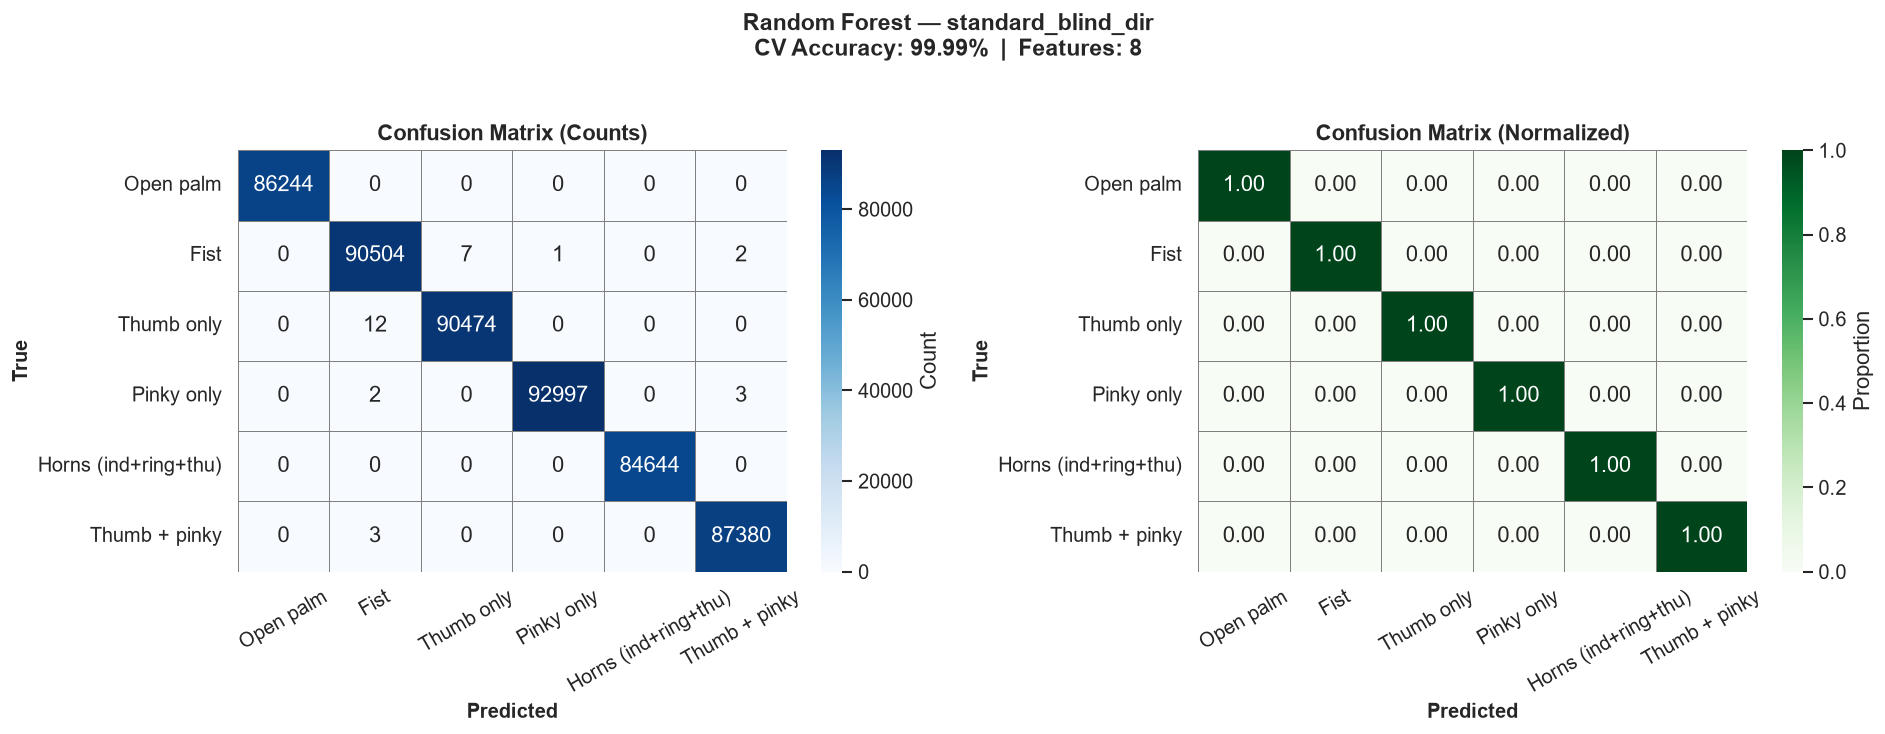

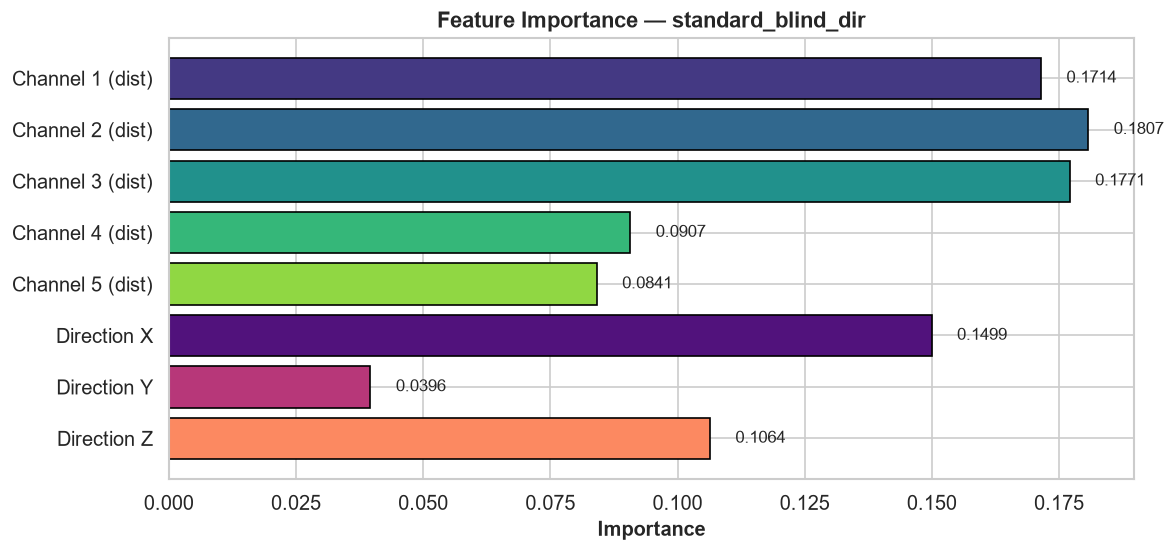

In [20]:
all_metrics = []
trained_models = {}

for i_model, cfg in enumerate(MODEL_CONFIGS, 1):
    print()
    print("=" * 80)
    print(f"  MODEL {i_model}/{len(MODEL_CONFIGS)} \u2014 {cfg['name'].upper()} ({cfg['description']})")
    print("=" * 80)
    print()

    # Prepare features from raw data (no aggregation)
    X, y, feature_cols = prepare_features(
        df, include_direction=cfg['use_direction']
    )

    print(f"[DATA] Feature matrix shape: {X.shape}")
    print(f"[DATA] Feature names: {feature_cols}")
    print()

    # Train with GridSearchCV + progress bar
    t0 = time.time()
    model, metrics = train_model(X, y, cfg['name'])
    print(f"\n[TOTAL] Model {cfg['name']} completed in {(time.time()-t0)/60:.1f} min")

    all_metrics.append(metrics)
    trained_models[cfg['name']] = (model, X, y, feature_cols)

    # Evaluation plots (inline)
    plot_confusion_matrix(model, X, y, cfg['name'], feature_cols)


## 8. Summary

In [21]:
df_metrics = pd.DataFrame(all_metrics)
df_metrics[['Model', 'Accuracy', 'Acc_Std', 'F1_Macro', 'F1_Std',
             'n_estimators', 'max_depth', 'Samples']]

,Model,Accuracy,Acc_Std,F1_Macro,F1_Std,n_estimators,max_depth,Samples
0,standard_blind,0.993205,0.000227,0.993347,0.000222,200,None,532273
1,standard_blind_dir,0.999944,0.000021,0.999945,0.000021,50,None,532273


## 9. Comparison Plot

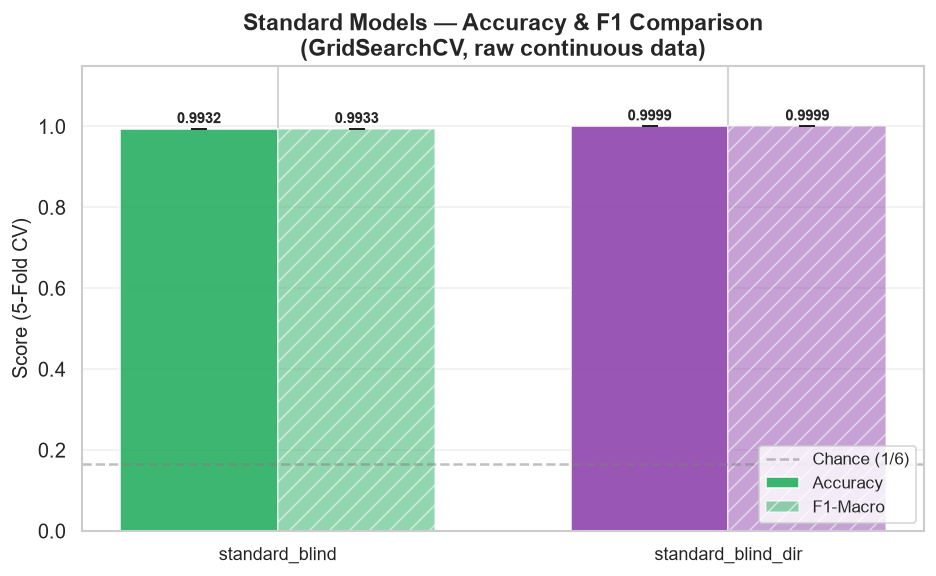


[OK] All done!


In [22]:
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(MODEL_CONFIGS))
w_bar = 0.35

acc_vals = [m['Accuracy'] for m in all_metrics]
acc_stds = [m['Acc_Std'] for m in all_metrics]
f1_vals  = [m['F1_Macro'] for m in all_metrics]
f1_stds  = [m['F1_Std'] for m in all_metrics]
names    = [m['Model'] for m in all_metrics]
colors   = [c['color'] for c in MODEL_CONFIGS]

bars1 = ax.bar(x - w_bar/2, acc_vals, w_bar, yerr=acc_stds,
               label='Accuracy', color=colors, edgecolor='white',
               capsize=5, alpha=0.9)
bars2 = ax.bar(x + w_bar/2, f1_vals, w_bar, yerr=f1_stds,
               label='F1-Macro', color=colors, edgecolor='white',
               capsize=5, alpha=0.5, hatch='//')

for b, v in zip(bars1, acc_vals):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.015,
            f'{v:.4f}', ha='center', fontsize=9, fontweight='bold')
for b, v in zip(bars2, f1_vals):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.015,
            f'{v:.4f}', ha='center', fontsize=9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(names, fontsize=11)
ax.set_ylabel('Score (5-Fold CV)', fontsize=12)
ax.set_title('Standard Models — Accuracy & F1 Comparison\n'
             '(GridSearchCV, raw continuous data)',
             fontsize=14, fontweight='bold')
ax.set_ylim(0, 1.15)
ax.axhline(y=1/6, color='grey', ls='--', alpha=0.5, label='Chance (1/6)')
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print("\n[OK] All done!")

## 10. Feature Importance Comparison

A side-by-side comparison of the feature importances for the 5 shared distance channels. This shows how the model re-weights the spatial channels when directional information is added.

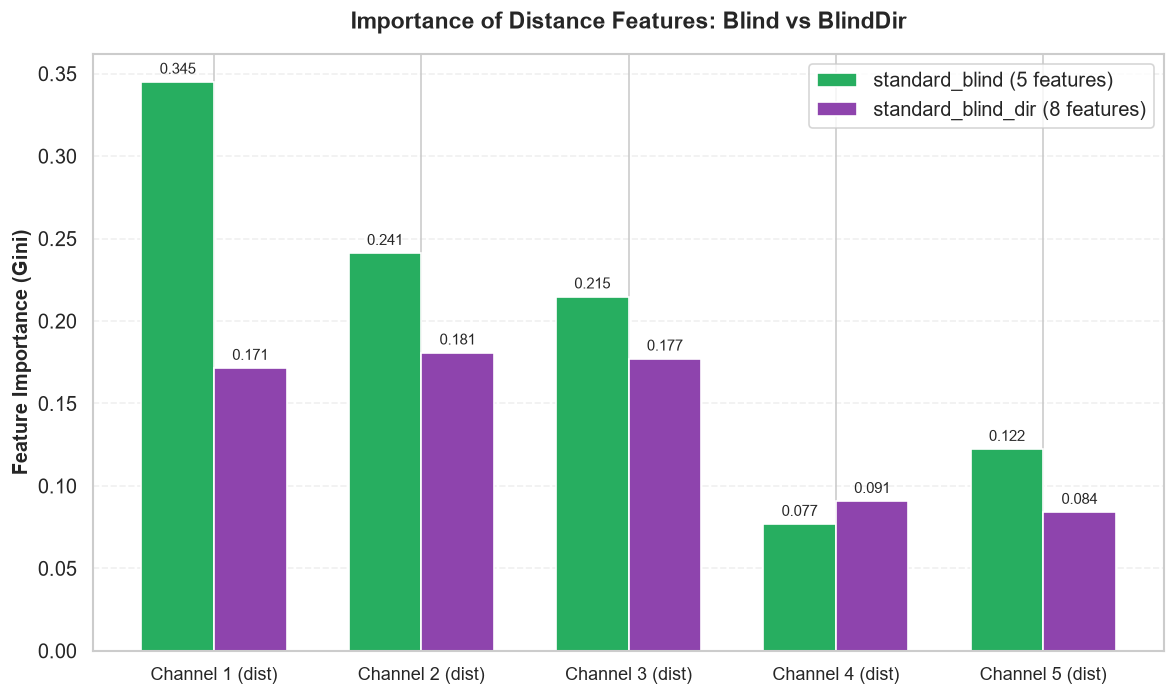

In [23]:
if 'trained_models' in locals() and len(trained_models) == 2:
    m1_name = MODEL_CONFIGS[0]['name']
    m2_name = MODEL_CONFIGS[1]['name']
    
    m1 = trained_models[m1_name][0]
    m2 = trained_models[m2_name][0]
    
    # Extract importances for the first 5 features (distances)
    imp1 = m1.feature_importances_[:5]
    imp2 = m2.feature_importances_[:5]
    
    labels = ["Channel 1 (dist)", "Channel 2 (dist)", "Channel 3 (dist)", "Channel 4 (dist)", "Channel 5 (dist)"]
    
    x = np.arange(len(labels))
    width = 0.35
    
    fig, ax = plt.subplots(figsize=(10, 6))
    bars1 = ax.bar(x - width/2, imp1, width, label=f'{m1_name} (5 features)', color=MODEL_CONFIGS[0]['color'], edgecolor='white')
    bars2 = ax.bar(x + width/2, imp2, width, label=f'{m2_name} (8 features)', color=MODEL_CONFIGS[1]['color'], edgecolor='white')
    
    ax.set_ylabel('Feature Importance (Gini)', fontsize=12, fontweight='bold')
    ax.set_title('Importance of Distance Features: Blind vs BlindDir', fontsize=14, fontweight='bold', pad=15)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=11)
    ax.legend()
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    
    for b in bars1:
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.005,
                f'{b.get_height():.3f}', ha='center', fontsize=9)
    for b in bars2:
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.005,
                f'{b.get_height():.3f}', ha='center', fontsize=9)
                
    plt.tight_layout()
    plt.show()


## 11. Hyperparameters Distribution (Radar)

Visualizing the best hyperparameters found by GridSearchCV for both models on a radar chart.

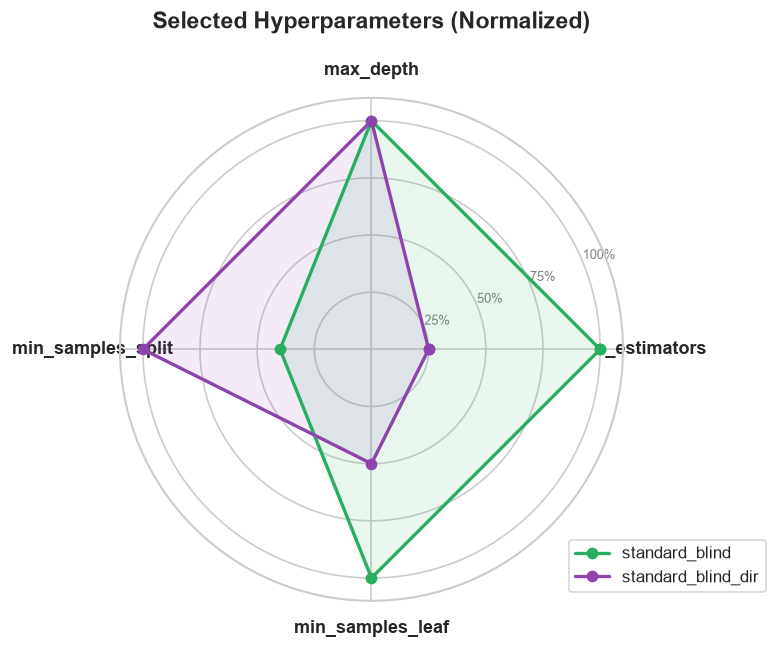

In [24]:
if all_metrics:
    from math import pi
    
    hp_keys = ['n_estimators', 'max_depth', 'min_samples_split', 'min_samples_leaf']
    
    # Normalize values for radar chart
    max_vals = {
        'n_estimators': 200,
        'max_depth': 20,
        'min_samples_split': 5,
        'min_samples_leaf': 2
    }
    
    N = len(hp_keys)
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]
    
    fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
    
    for i, config in enumerate(MODEL_CONFIGS):
        metric = next(m for m in all_metrics if m['Model'] == config['name'])
        
        values = []
        for k in hp_keys:
            val = metric[k]
            # Handle None for max_depth
            if k == 'max_depth' and val is None:
                val = 20 # Assume max depth allowed in grid or unconstrained
            
            # Normalize to 0-1
            norm_val = val / max_vals[k]
            values.append(norm_val)
            
        values += values[:1]
        
        ax.plot(angles, values, 'o-', linewidth=2, label=config['name'], color=config['color'])
        ax.fill(angles, values, alpha=0.1, color=config['color'])
        
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(hp_keys, fontsize=11, fontweight='bold')
    ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(['25%', '50%', '75%', '100%'], color="grey", size=8)
    ax.set_ylim(0, 1.1)
    ax.set_title('Selected Hyperparameters (Normalized)', fontsize=14, fontweight='bold', pad=20)
    ax.legend(loc='lower right', bbox_to_anchor=(1.3, 0), fontsize=10)
    
    plt.tight_layout()
    plt.show()


## 10. Feature Importance Comparison

A side-by-side comparison of the feature importances for the 5 shared distance channels. This shows how the model re-weights the spatial channels when directional information is added.

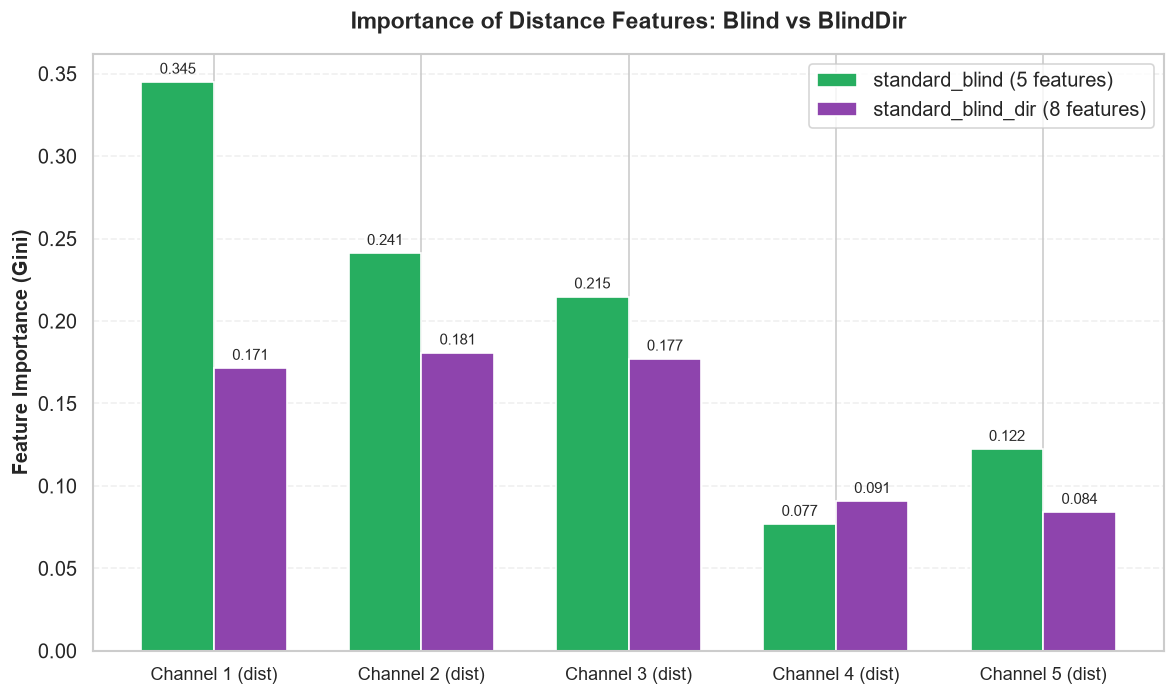

In [25]:
if 'trained_models' in locals() and len(trained_models) == 2:
    m1_name = MODEL_CONFIGS[0]['name']
    m2_name = MODEL_CONFIGS[1]['name']
    
    m1 = trained_models[m1_name][0]
    m2 = trained_models[m2_name][0]
    
    # Extract importances for the first 5 features (distances)
    imp1 = m1.feature_importances_[:5]
    imp2 = m2.feature_importances_[:5]
    
    labels = ["Channel 1 (dist)", "Channel 2 (dist)", "Channel 3 (dist)", "Channel 4 (dist)", "Channel 5 (dist)"]
    
    x = np.arange(len(labels))
    width = 0.35
    
    fig, ax = plt.subplots(figsize=(10, 6))
    bars1 = ax.bar(x - width/2, imp1, width, label=f'{m1_name} (5 features)', color=MODEL_CONFIGS[0]['color'], edgecolor='white')
    bars2 = ax.bar(x + width/2, imp2, width, label=f'{m2_name} (8 features)', color=MODEL_CONFIGS[1]['color'], edgecolor='white')
    
    ax.set_ylabel('Feature Importance (Gini)', fontsize=12, fontweight='bold')
    ax.set_title('Importance of Distance Features: Blind vs BlindDir', fontsize=14, fontweight='bold', pad=15)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=11)
    ax.legend()
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    
    for b in bars1:
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.005,
                f'{b.get_height():.3f}', ha='center', fontsize=9)
    for b in bars2:
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.005,
                f'{b.get_height():.3f}', ha='center', fontsize=9)
                
    plt.tight_layout()
    plt.show()


## 11. Hyperparameters Distribution (Radar)

Visualizing the best hyperparameters found by GridSearchCV for both models on a radar chart.

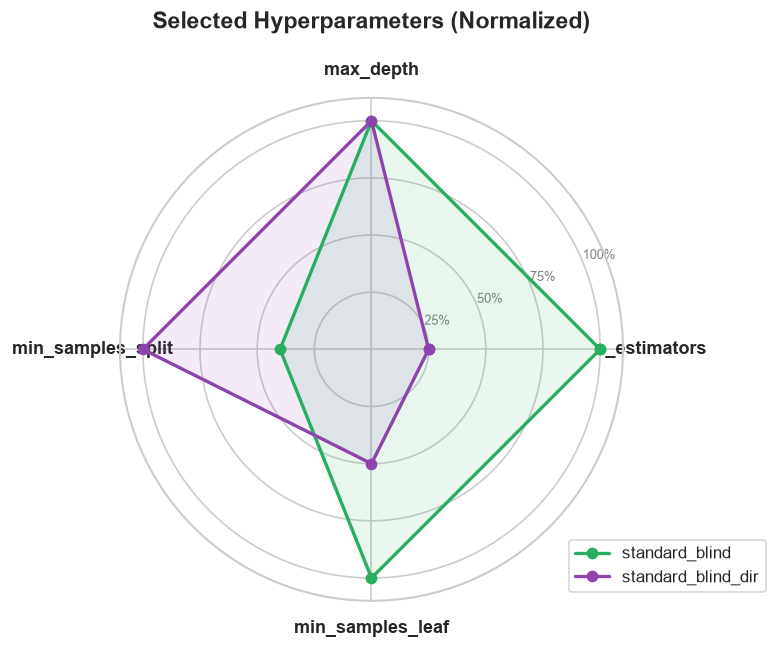

In [26]:
if all_metrics:
    from math import pi
    
    hp_keys = ['n_estimators', 'max_depth', 'min_samples_split', 'min_samples_leaf']
    
    # Normalize values for radar chart
    max_vals = {
        'n_estimators': 200,
        'max_depth': 20,
        'min_samples_split': 5,
        'min_samples_leaf': 2
    }
    
    N = len(hp_keys)
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]
    
    fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
    
    for i, config in enumerate(MODEL_CONFIGS):
        metric = next(m for m in all_metrics if m['Model'] == config['name'])
        
        values = []
        for k in hp_keys:
            val = metric[k]
            # Handle None for max_depth
            if k == 'max_depth' and val is None:
                val = 20 # Assume max depth allowed in grid or unconstrained
            
            # Normalize to 0-1
            norm_val = val / max_vals[k]
            values.append(norm_val)
            
        values += values[:1]
        
        ax.plot(angles, values, 'o-', linewidth=2, label=config['name'], color=config['color'])
        ax.fill(angles, values, alpha=0.1, color=config['color'])
        
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(hp_keys, fontsize=11, fontweight='bold')
    ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(['25%', '50%', '75%', '100%'], color="grey", size=8)
    ax.set_ylim(0, 1.1)
    ax.set_title('Selected Hyperparameters (Normalized)', fontsize=14, fontweight='bold', pad=20)
    ax.legend(loc='lower right', bbox_to_anchor=(1.3, 0), fontsize=10)
    
    plt.tight_layout()
    plt.show()
